# Notebook 1: Exploratory Data Analysis

This notebook explores the two datasets:
- `ratings.csv` — user-course interactions with ratings
- `course_genre.csv` — course metadata with genre/tag labels

In [108]:
from pathlib import Path

# ── Paths ───────────────────────────────────────────
DATA_DIR    = Path('data/raw')
FIGURES_DIR = Path('figures/eda')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Plot style ──────────────────────────────────────
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})
PALETTE = 'viridis'


## 1. Load Data

In [109]:
ratings    = pd.read_csv(DATA_DIR / 'ratings.csv')
courses    = pd.read_csv(DATA_DIR / 'course_genre.csv')

print("Ratings shape :", ratings.shape)
print("Courses shape :", courses.shape)
ratings.head()


Ratings shape : (233306, 3)
Courses shape : (307, 16)


,user,item,rating
0,1889878,CC0101EN,3.0
1,1342067,CL0101EN,3.0
2,1990814,ML0120ENv3,3.0
3,380098,BD0211EN,3.0
4,779563,DS0101EN,3.0


In [110]:
courses.head()

,COURSE_ID,TITLE,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain
0,ML0201EN,robots are coming build iot apps with watson ...,0,0,0,0,0,0,0,0,0,0,0,1,1,0
1,ML0122EN,accelerating deep learning with gpu,0,1,0,0,0,1,0,1,0,0,0,0,0,0
2,GPXX0ZG0EN,consuming restful services using the reactive ...,0,0,0,0,0,0,0,0,0,0,0,1,1,0
3,RP0105EN,analyzing big data in r using apache spark,1,0,0,1,0,0,0,0,1,0,1,0,0,0
4,GPXX0Z2PEN,containerizing packaging and running a sprin...,0,0,0,0,1,0,0,0,0,0,0,1,0,0


## 2. Ratings Dataset – Basic Statistics

In [111]:
print("=== ratings.csv ===")
print(ratings.dtypes)
print("\nMissing values:")
print(ratings.isnull().sum())
print("\nRating stats:")
ratings['rating'].describe()


=== ratings.csv ===
user        int64
item       object
rating    float64
dtype: object

Missing values:
user      0
item      0
rating    0
dtype: int64

Rating stats:


count    233306.000000
mean          2.952954
std           0.211737
min           2.000000
25%           3.000000
50%           3.000000
75%           3.000000
max           3.000000
Name: rating, dtype: float64

In [112]:
# Unique counts
print(f"Unique users   : {ratings['user'].nunique():,}")
print(f"Unique courses : {ratings['item'].nunique():,}")
print(f"Total ratings  : {len(ratings):,}")
sparsity = 1 - len(ratings) / (ratings['user'].nunique() * ratings['item'].nunique())
print(f"Matrix sparsity: {sparsity:.4%}")


Unique users   : 33,901
Unique courses : 126
Total ratings  : 233,306
Matrix sparsity: 94.5381%


## 3. Rating Distribution

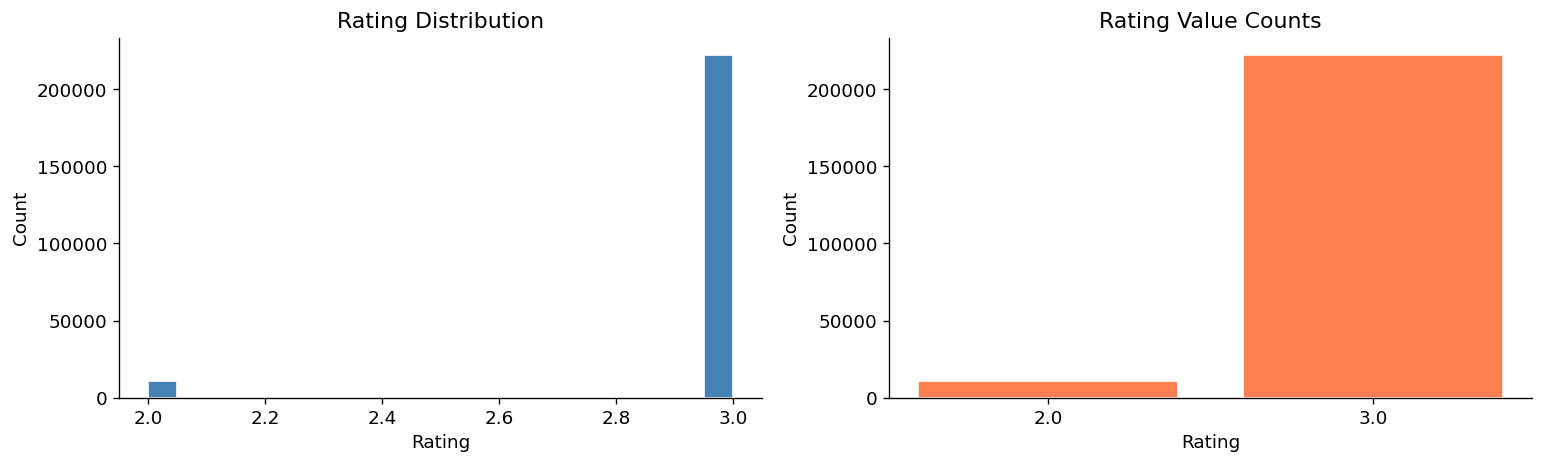

rating
2.0     10976
3.0    222330
Name: count, dtype: int64


In [113]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
axes[0].hist(ratings['rating'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Rating'); axes[0].set_ylabel('Count')

# Value counts bar
vc = ratings['rating'].value_counts().sort_index()
axes[1].bar(vc.index.astype(str), vc.values, color='coral', edgecolor='white')
axes[1].set_title('Rating Value Counts')
axes[1].set_xlabel('Rating'); axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_rating_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print(vc)


* Major Class: The dataset is heavily skewed toward a rating of 3.0, which accounts for over 200,000 entries.

* Minority Class: Ratings of 2.0 are significantly less frequent, representing only a small fraction of the total data.

## 4. User Activity Analysis

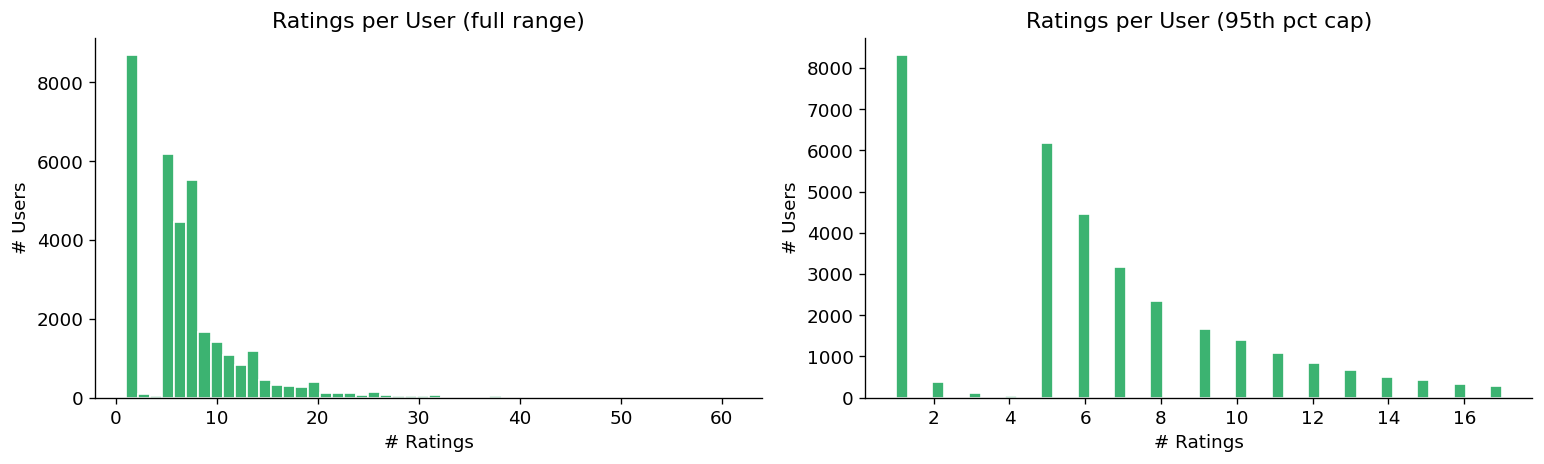

count    33901.000000
mean         6.881980
std          5.823548
min          1.000000
25%          2.000000
50%          6.000000
75%          9.000000
max         61.000000
Name: item, dtype: float64


In [114]:
user_counts = ratings.groupby('user')['item'].count().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(user_counts, bins=50, color='mediumseagreen', edgecolor='white')
axes[0].set_title('Ratings per User (full range)')
axes[0].set_xlabel('# Ratings'); axes[0].set_ylabel('# Users')

axes[1].hist(user_counts[user_counts <= user_counts.quantile(0.95)], bins=50,
             color='mediumseagreen', edgecolor='white')
axes[1].set_title('Ratings per User (95th pct cap)')
axes[1].set_xlabel('# Ratings'); axes[1].set_ylabel('# Users')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_user_activity.png', bbox_inches='tight', dpi=150)
plt.show()
print(user_counts.describe())


* Sparsity & Engagement: A large majority of users have very few ratings, with the most frequent count being just 1 rating per user. This indicates a high level of data sparsity, which is a common challenge in recommendation systems.

* Central Tendency: The median (50%) is 6.0, while the mean is 6.88. Since the mean is higher than the median, the distribution is positively skewed, confirming a "long tail" of highly active users.

* Activity Spread: While most users fall within the 1–17 range (as seen in the 95th percentile cap), there are "power users" who have contributed up to 61 ratings.

## 5. Course Popularity

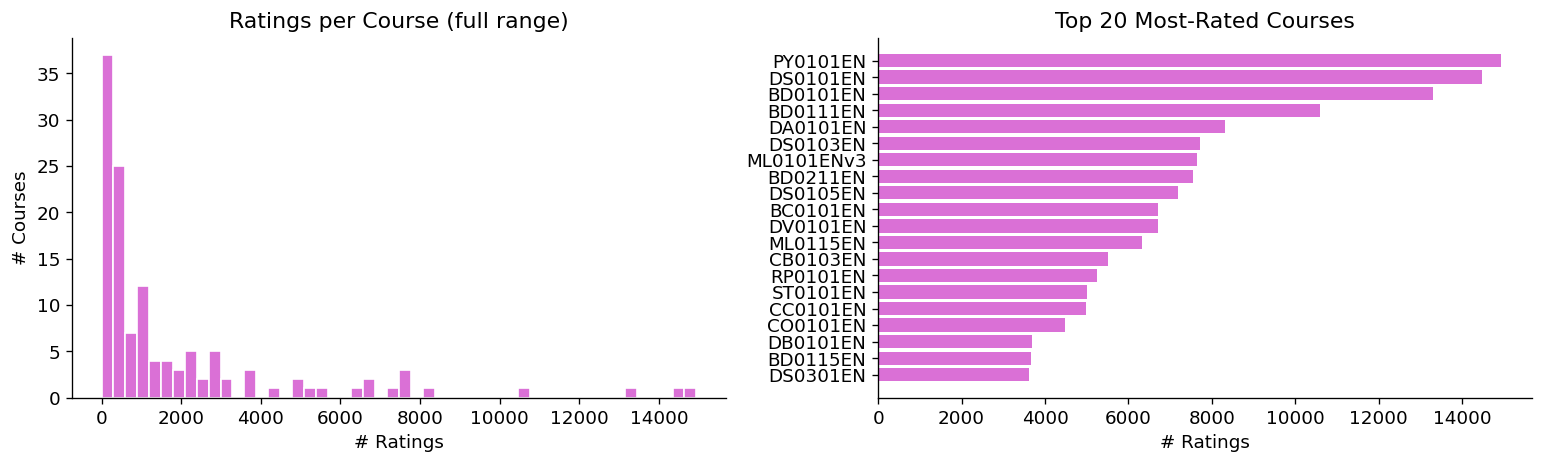

In [115]:
course_counts = ratings.groupby('item')['user'].count().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(course_counts, bins=50, color='orchid', edgecolor='white')
axes[0].set_title('Ratings per Course (full range)')
axes[0].set_xlabel('# Ratings'); axes[0].set_ylabel('# Courses')

top20 = course_counts.head(20)
axes[1].barh(top20.index[::-1], top20.values[::-1], color='orchid')
axes[1].set_title('Top 20 Most-Rated Courses')
axes[1].set_xlabel('# Ratings')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_course_popularity.png', bbox_inches='tight', dpi=150)
plt.show()


* Popularity Bias: The horizontal bar chart identifies the top performers, primarily fundamental courses like PY0101EN (Python) and DS0101EN (Data Science). These "head" items have over 14,000 ratings each, making them the most visible entries in the system.

* The Long Tail: The histogram illustrates a classic power-law distribution. While a few courses are massive hits, the vast majority of the catalog resides in the "long tail"—courses with significantly fewer ratings.

* Recommendation Challenge: Because the data is so concentrated on the top 20 courses, a basic algorithm might naturally lean toward recommending these "safe" popular choices.

Rated courses   : 126
Unrated courses : 181
Coverage        : 41.04%


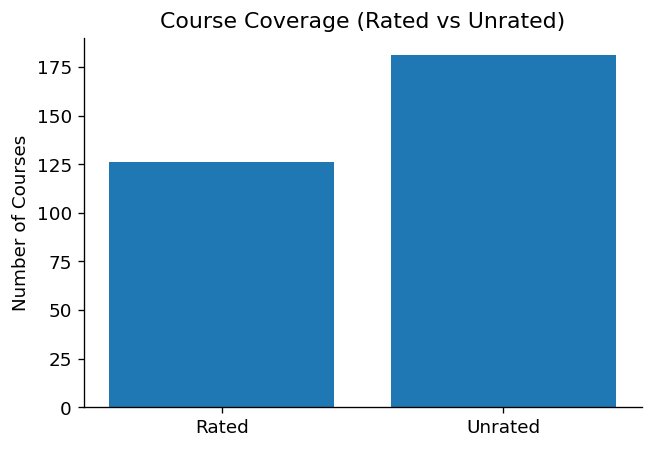

In [116]:
# ── Coverage Analysis ─────────────────────────────
rated_ids     = set(ratings['item'].unique())
catalogue_ids = set(courses['COURSE_ID'].unique())

num_rated   = len(rated_ids)
num_total   = len(catalogue_ids)
num_unrated = num_total - num_rated

print(f"Rated courses   : {num_rated}")
print(f"Unrated courses : {num_unrated}")
print(f"Coverage        : {num_rated / num_total:.2%}")

# Plot
plt.figure(figsize=(6,4))
plt.bar(['Rated', 'Unrated'], [num_rated, num_unrated])
plt.title('Course Coverage (Rated vs Unrated)')
plt.ylabel('Number of Courses')
plt.savefig(FIGURES_DIR / '08_course_coverage.png', dpi=150)
plt.show()

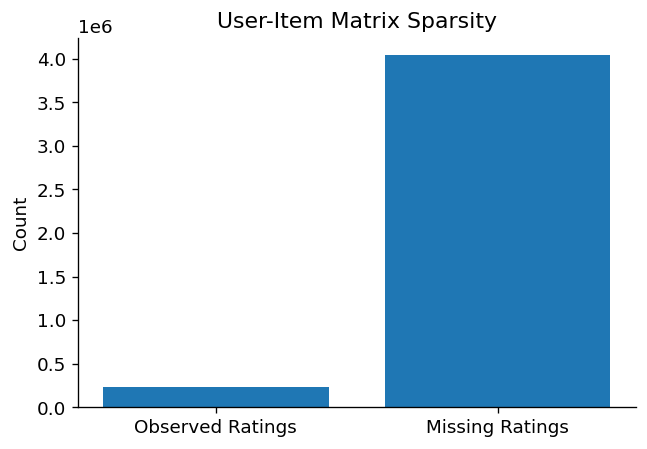

In [117]:
# ── Sparsity Visualization ────────────────────────
matrix_size = ratings['user'].nunique() * ratings['item'].nunique()
observed = len(ratings)

plt.figure(figsize=(6,4))
plt.bar(['Observed Ratings', 'Missing Ratings'],
        [observed, matrix_size - observed])
plt.title('User-Item Matrix Sparsity')
plt.ylabel('Count')
plt.savefig(FIGURES_DIR / '09_sparsity.png', dpi=150)
plt.show()

In [ ]:
# ── Cold Start Courses - we matched the course_id with "item" in the ratings dataset. ────────────────────────────
unrated_courses = courses[
    ~courses['COURSE_ID'].isin(ratings['item'])
]

print(f"Cold-start courses: {len(unrated_courses)}")
unrated_courses.head()

Cold-start courses: 181


,COURSE_ID,TITLE,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain
2,GPXX0ZG0EN,consuming restful services using the reactive ...,0,0,0,0,0,0,0,0,0,0,0,1,1,0
4,GPXX0Z2PEN,containerizing packaging and running a sprin...,0,0,0,0,1,0,0,0,0,0,0,1,0,0
7,GPXX0FTCEN,learn how to use docker containers for iterati...,0,0,0,0,1,0,0,0,0,0,0,0,0,0
9,GPXX06RFEN,create your first mongodb database,1,0,0,0,0,0,0,0,0,0,0,0,0,0
10,GPXX0SDXEN,testing microservices with the arquillian mana...,0,0,0,0,1,0,0,0,0,0,0,1,0,0


## 6. Average Rating per Course (Top 20)

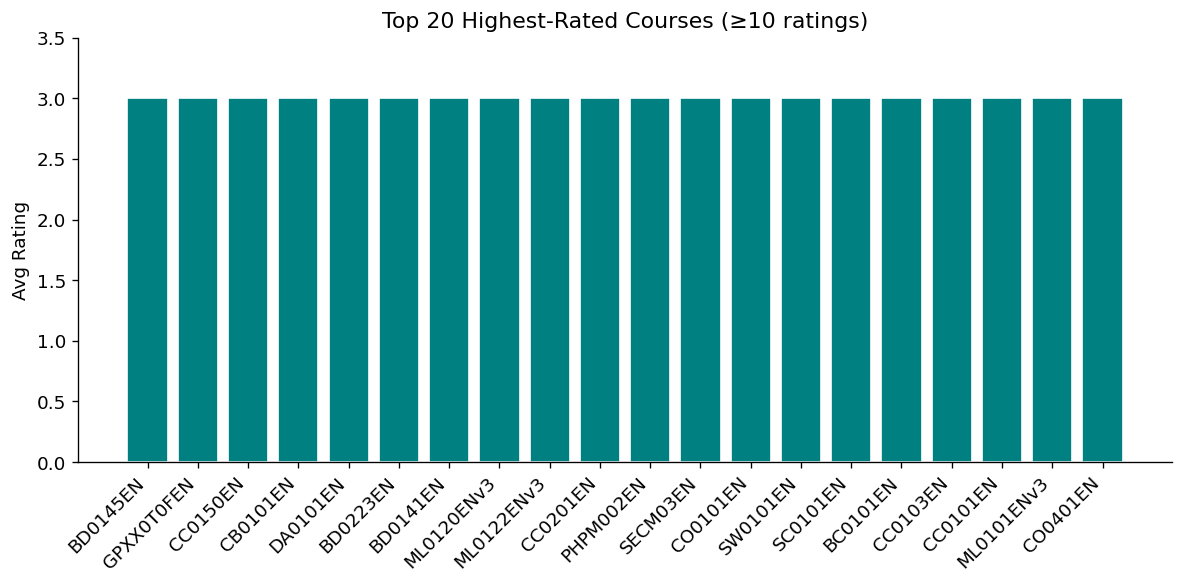

In [119]:
avg_rating = ratings.groupby('item')['rating'].mean().sort_values(ascending=False)
top20_avg = avg_rating[course_counts[avg_rating.index] >= 10].head(20)  # at least 10 ratings

plt.figure(figsize=(10, 5))
plt.bar(range(len(top20_avg)), top20_avg.values, color='teal', edgecolor='white')
plt.xticks(range(len(top20_avg)), top20_avg.index, rotation=45, ha='right')
plt.title('Top 20 Highest-Rated Courses (≥10 ratings)')
plt.ylabel('Avg Rating'); plt.ylim(0, 3.5)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_avg_rating_top20.png', bbox_inches='tight', dpi=150)
plt.show()


* Uniform Excellence: Every course in the top 20 maintains a perfect average rating of 3.0. This aligns with our earlier finding that 3.0 is the most frequent rating in the dataset.

* Filtering for Reliability: By excluding courses with fewer than 10 ratings, we avoid "lucky" high scores from single users, focusing instead on content that consistently satisfies a broader audience.

* Modeling Implication: Since these courses represent the gold standard in the current dataset, they serve as excellent candidates for "Top-Rated" baseline recommendations.

## 7. Course Genre / Metadata Analysis

In [120]:
print("=== course_genre.csv ===")
print(courses.dtypes)
print("\nMissing values:")
print(courses.isnull().sum())
courses.describe()


=== course_genre.csv ===
COURSE_ID          object
TITLE              object
Database            int64
Python              int64
CloudComputing      int64
DataAnalysis        int64
Containers          int64
MachineLearning     int64
ComputerVision      int64
DataScience         int64
BigData             int64
Chatbot             int64
R                   int64
BackendDev          int64
FrontendDev         int64
Blockchain          int64
dtype: object

Missing values:
COURSE_ID          0
TITLE              0
Database           0
Python             0
CloudComputing     0
DataAnalysis       0
Containers         0
MachineLearning    0
ComputerVision     0
DataScience        0
BigData            0
Chatbot            0
R                  0
BackendDev         0
FrontendDev        0
Blockchain         0
dtype: int64


,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain
count,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000
mean,0.195440,0.091205,0.120521,0.182410,0.055375,0.224756,0.032573,0.123779,0.117264,0.013029,0.055375,0.254072,0.061889,0.013029
std,0.397186,0.288371,0.326102,0.386813,0.229083,0.418103,0.177807,0.329866,0.322260,0.113585,0.229083,0.436049,0.241348,0.113585
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


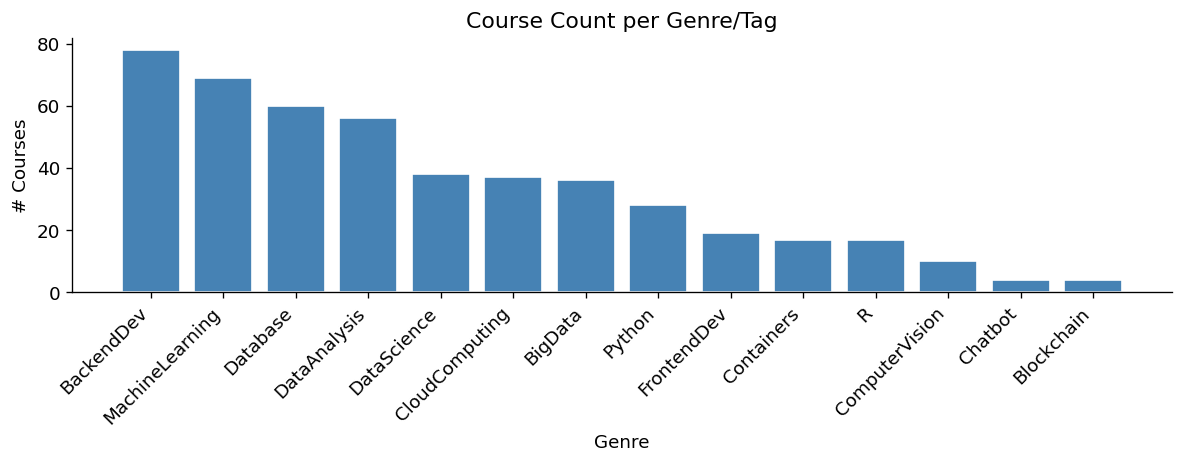

BackendDev         78
MachineLearning    69
Database           60
DataAnalysis       56
DataScience        38
CloudComputing     37
BigData            36
Python             28
FrontendDev        19
Containers         17
R                  17
ComputerVision     10
Chatbot             4
Blockchain          4
dtype: int64


In [121]:
genre_cols = courses.columns[2:].tolist()   # skip COURSE_ID and TITLE
genre_sums = courses[genre_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
plt.bar(genre_sums.index, genre_sums.values, color='steelblue', edgecolor='white')
plt.title('Course Count per Genre/Tag')
plt.xlabel('Genre'); plt.ylabel('# Courses')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '05_genre_counts.png', bbox_inches='tight', dpi=150)
plt.show()
print(genre_sums)


* Core Strengths: The catalog is heavily focused on Backend Development (78 courses), Machine Learning (69 courses), and Database (60 courses). These three genres form the backbone of the available content.

* Data Science Ecosystem: There is a strong secondary cluster of data-centric topics, including Data Analysis, Data Science, and Big Data, which combined represent a significant portion of the platform's educational value.

## 8. Multi-Genre Distribution

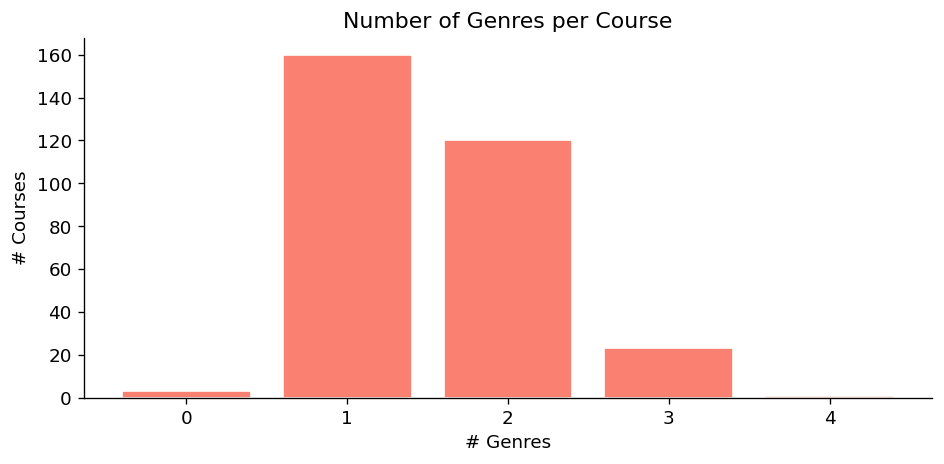

num_genres
0      3
1    160
2    120
3     23
4      1
Name: count, dtype: int64


In [122]:
courses['num_genres'] = courses[genre_cols].sum(axis=1)

plt.figure(figsize=(8, 4))
vc2 = courses['num_genres'].value_counts().sort_index()
plt.bar(vc2.index.astype(str), vc2.values, color='salmon', edgecolor='white')
plt.title('Number of Genres per Course')
plt.xlabel('# Genres'); plt.ylabel('# Courses')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '06_multi_genre_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print(vc2)


* Primary Distribution: The vast majority of courses are focused, with 160 courses belonging to a single genre and 120 courses spanning two. This suggests that while most content is specialized, there is significant overlap between related fields (e.g., Data Science and Python).

* The Specialists: Only a small fraction (23 courses) are tagged with three genres, and just one course reaches four. These represent highly interdisciplinary content.

* Data Integrity Note: There are 3 courses with zero genres. These may represent "placeholder" entries or generic content that might require manual tagging or could potentially be excluded to maintain the quality of the recommendation engine.

* Impact on Recommendations: Courses with multiple genres act as "bridges" in a recommendation graph, helping users transition from one subject area to another.

## 9. Genre Co-occurrence Heatmap

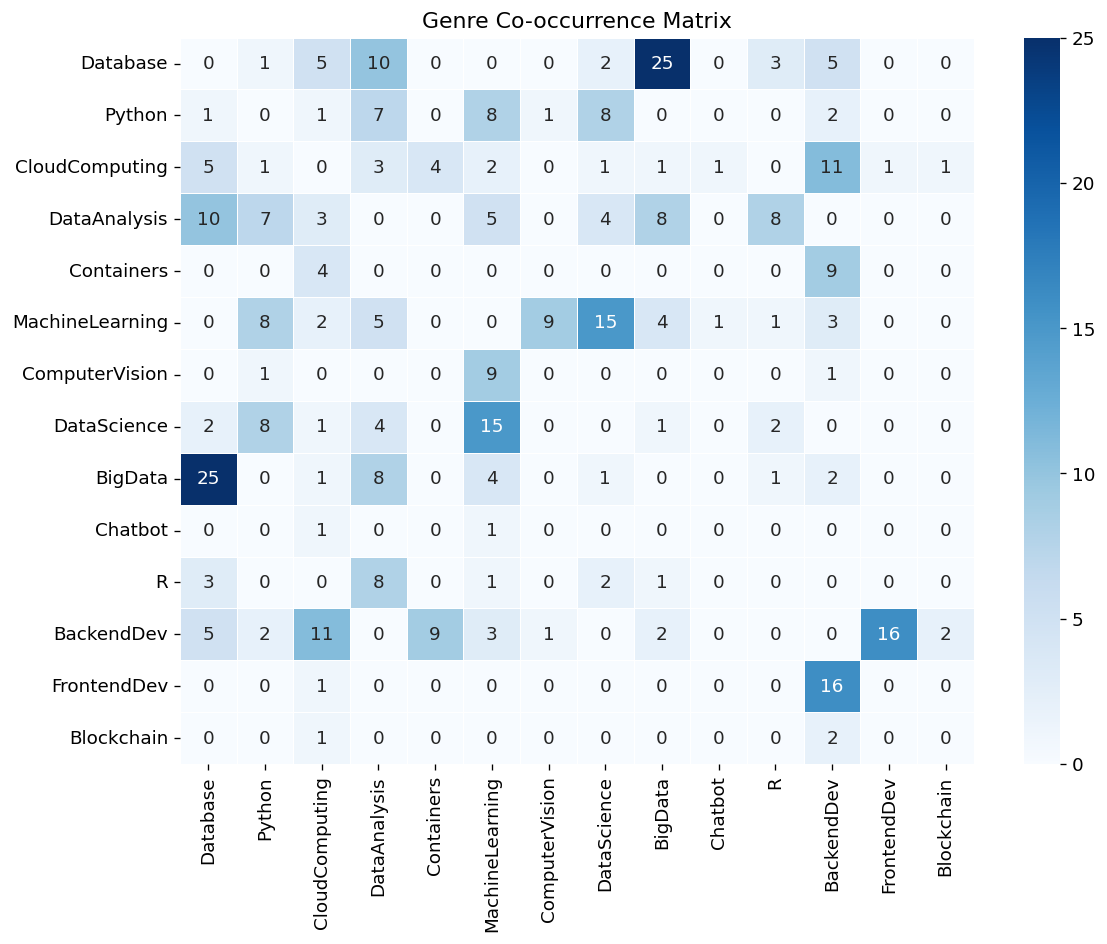

In [123]:
co = courses[genre_cols].T.dot(courses[genre_cols])
np.fill_diagonal(co.values, 0)

plt.figure(figsize=(10, 8))
sns.heatmap(co, annot=True, fmt='d', cmap='Blues', linewidths=0.5)
plt.title('Genre Co-occurrence Matrix')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '07_genre_cooccurrence_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()


* Dominant Partnerships: The strongest relationship exists between BigData and Database (25 co-occurrences), followed closely by Machine Learning and Data Science (15). These high-density cells indicate natural learning paths or "bundles" that are highly prevalent in the dataset.

* Engineering Clusters: BackendDev and FrontendDev (16) show a significant overlap, reflecting full-stack development content. There is also a notable connection between BackendDev and Cloud Computing (11).

* Specialized Islands: Genres like Chatbot, Blockchain, and Computer Vision show very little co-occurrence with other fields, indicating they are treated as highly specialized, stand-alone subjects within this catalog.

* Strategic Recommendation Insight: These co-occurrences are goldmines for a Content-Based Filtering system. If a user finishes a "Database" course, the system can confidently suggest "Big Data" content because of the strong thematic link established here.

## 10. Overlap: Rated Courses vs Catalogue

In [124]:
rated_ids    = set(ratings['item'].unique())
catalogue_ids = set(courses['COURSE_ID'].unique())
overlap = rated_ids & catalogue_ids

print(f"Courses in ratings         : {len(rated_ids):,}")
print(f"Courses in catalogue       : {len(catalogue_ids):,}")
print(f"Overlap (both datasets)    : {len(overlap):,}")
print(f"Rated but NOT in catalogue : {len(rated_ids - catalogue_ids):,}")
print(f"Catalogue but NOT rated    : {len(catalogue_ids - rated_ids):,}")


Courses in ratings         : 126
Courses in catalogue       : 307
Overlap (both datasets)    : 126
Rated but NOT in catalogue : 0
Catalogue but NOT rated    : 181


- Perfect Mapping: The 0 courses in "Rated but NOT in catalogue" indicates excellent data integrity. Every course that has been rated by a user exists within our metadata file, meaning we won't encounter "orphan" IDs during the recommendation process.

- Active vs. Passive Catalog: Out of 307 total courses, only 126 (approx. 41%) have actually received ratings. This means a significant portion of the catalog (181 courses) currently has no user feedback.

- Recommendation Strategy:

For the 126 Rated Courses: We can use Collaborative Filtering or Hybrid methods since we have interaction data.

For the 181 Unrated Courses: These represent a "Cold Start" problem for items. We will need to rely heavily on Content-Based Filtering (using the genres and descriptions analyzed earlier) to recommend these to users, as there is no rating history to leverage.

In [125]:
# ── Merge ratings + course features ───────────────
merged = ratings.merge(
    courses,
    left_on='item',
    right_on='COURSE_ID',
    how='left'
)

print("Merged shape:", merged.shape)
merged.head()

Merged shape: (233306, 20)


,user,item,rating,COURSE_ID,TITLE,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain,num_genres
0,1889878,CC0101EN,3.0,CC0101EN,introduction to cloud,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1
1,1342067,CL0101EN,3.0,CL0101EN,ibm cloud essentials,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1
2,1990814,ML0120ENv3,3.0,ML0120ENv3,deep learning with tensorflow,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1
3,380098,BD0211EN,3.0,BD0211EN,spark fundamentals i,1,0,0,1,0,0,0,0,1,0,0,0,0,0,3
4,779563,DS0101EN,3.0,DS0101EN,introduction to data science,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1


In [126]:
# ── Define correct column order ───────────────────

genre_cols = courses.columns[2:-1].tolist()  # all genre columns (skip COURSE_ID, TITLE, num_genres later)

final_columns = (
    ['COURSE_ID', 'TITLE'] +
    genre_cols +
    ['num_genres', 'user', 'rating']
)

# Apply order
merged = merged[final_columns]

merged.head()

,COURSE_ID,TITLE,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain,num_genres,user,rating
0,CC0101EN,introduction to cloud,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1889878,3.0
1,CL0101EN,ibm cloud essentials,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1342067,3.0
2,ML0120ENv3,deep learning with tensorflow,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1990814,3.0
3,BD0211EN,spark fundamentals i,1,0,0,1,0,0,0,0,1,0,0,0,0,0,3,380098,3.0
4,DS0101EN,introduction to data science,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,779563,3.0


In [ ]:

## we dropped exact duplicated rows .. 
merged = merged.drop_duplicates()

# Ensure no duplicate (user, course)
merged = merged.drop_duplicates(subset=['user', 'COURSE_ID'])

In [128]:
print("Missing after merge:")
print(merged.isnull().sum())

Missing after merge:
COURSE_ID          0
TITLE              0
Database           0
Python             0
CloudComputing     0
DataAnalysis       0
Containers         0
MachineLearning    0
ComputerVision     0
DataScience        0
BigData            0
Chatbot            0
R                  0
BackendDev         0
FrontendDev        0
Blockchain         0
num_genres         0
user               0
rating             0
dtype: int64


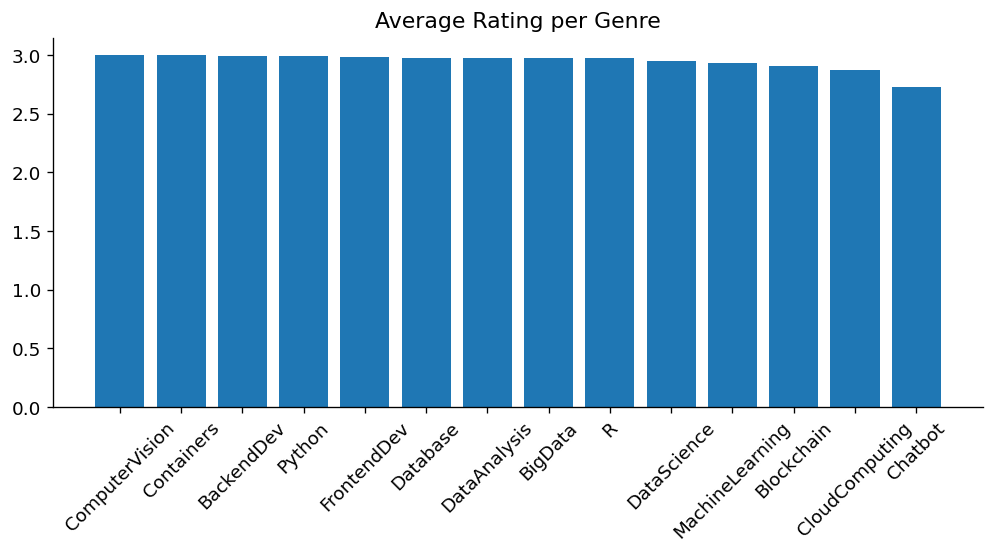

ComputerVision     3.000000
Containers         2.999291
BackendDev         2.994823
Python             2.989852
FrontendDev        2.987165
Database           2.977496
DataAnalysis       2.976480
BigData            2.975592
R                  2.973705
DataScience        2.952629
MachineLearning    2.933873
Blockchain         2.909130
CloudComputing     2.871150
Chatbot            2.729264
dtype: float64


In [129]:
# ── Genre vs Rating Analysis ─────────────────────
genre_means = {}

for col in genre_cols:
    genre_means[col] = merged[merged[col] == 1]['rating'].mean()

genre_means = pd.Series(genre_means).sort_values(ascending=False)

plt.figure(figsize=(10,4))
plt.bar(genre_means.index, genre_means.values)
plt.title('Average Rating per Genre')
plt.xticks(rotation=45)
plt.savefig(FIGURES_DIR / '11_genre_vs_rating.png', dpi=150)
plt.show()

print(genre_means)

In [ ]:
# ── Detect duplicate course titles ───────────────
duplicates = courses[courses.duplicated('TITLE', keep=False)]

print(f"Duplicate titles: {len(duplicates)}")
duplicates[['COURSE_ID','TITLE']].sort_values('TITLE').head(20)

Duplicate titles: 26


,COURSE_ID,TITLE
1,ML0122EN,accelerating deep learning with gpu
57,ML0122ENv1,accelerating deep learning with gpu
262,excourse49,applied machine learning in python
234,excourse21,applied machine learning in python
146,CC0250EN,building cloud native and multicloud applications
207,CC0150EN,building cloud native and multicloud applications
249,excourse36,data analysis using python
236,excourse23,data analysis using python
251,excourse38,data analysis with python
161,DA0101EN,data analysis with python


In [131]:
courses['normalized_id'] = courses.groupby('TITLE')['COURSE_ID'].transform('first')

In [132]:
id_map = dict(zip(courses['COURSE_ID'], courses['normalized_id']))

In [133]:
ratings['normalized_id'] = ratings['item'].map(id_map)

In [134]:
merged = ratings.merge(
    courses,
    left_on='normalized_id',
    right_on='normalized_id',
    how='left'
)

In [155]:
courses.head()

,COURSE_ID,TITLE,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain,num_genres,normalized_id
0,ML0201EN,robots are coming build iot apps with watson ...,0,0,0,0,0,0,0,0,0,0,0,1,1,0,2,ML0201EN
1,ML0122EN,accelerating deep learning with gpu,0,1,0,0,0,1,0,1,0,0,0,0,0,0,3,ML0122EN
2,GPXX0ZG0EN,consuming restful services using the reactive ...,0,0,0,0,0,0,0,0,0,0,0,1,1,0,2,GPXX0ZG0EN
3,RP0105EN,analyzing big data in r using apache spark,1,0,0,1,0,0,0,0,1,0,1,0,0,0,4,RP0105EN
4,GPXX0Z2PEN,containerizing packaging and running a sprin...,0,0,0,0,1,0,0,0,0,0,0,1,0,0,2,GPXX0Z2PEN


In [156]:
from pathlib import Path

# Create folders
OUTPUT_DIR = Path("data/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Save dataset
courses.to_csv(OUTPUT_DIR / "final_courses.csv", index=False)

print("✅ Dataset saved at:", OUTPUT_DIR / "final_courses.csv")

✅ Dataset saved at: data/processed/final_courses.csv


In [135]:
merged = merged.drop_duplicates(subset=['user', 'normalized_id'])

In [136]:
merged = merged.rename(columns={'normalized_id': 'COURSE_ID'})
merged = merged.drop(columns=['item'])

In [137]:
merged['COURSE_ID'].nunique()

COURSE_ID    118
COURSE_ID    118
dtype: int64

In [145]:
courses['normalized_id'].nunique()

293

In [138]:
courses['COURSE_ID'].nunique()
courses['normalized_id'].nunique()

293

In [139]:
courses[courses['TITLE'] == 'deep learning with tensorflow']

,COURSE_ID,TITLE,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain,num_genres,normalized_id
110,ML0120EN,deep learning with tensorflow,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,ML0120EN
202,ML0120ENv2,deep learning with tensorflow,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,ML0120EN
212,ML0120ENv3,deep learning with tensorflow,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,ML0120EN


In [147]:
# ── Detect duplicate course titles ───────────────
duplicates = merged[merged.duplicated('TITLE', keep=False)]

print(f"Duplicate titles: {len(duplicates)}")
duplicates[['COURSE_ID','TITLE']].sort_values('TITLE').head(20)

Duplicate titles: 232854


,COURSE_ID,COURSE_ID,TITLE
115750,ML0122EN,ML0122EN,accelerating deep learning with gpu
232439,ML0122EN,ML0122EN,accelerating deep learning with gpu
109089,ML0122EN,ML0122EN,accelerating deep learning with gpu
64326,ML0122EN,ML0122EN,accelerating deep learning with gpu
257666,ML0122EN,ML0122EN,accelerating deep learning with gpu
213748,ML0122EN,ML0122EN,accelerating deep learning with gpu
109229,ML0122EN,ML0122EN,accelerating deep learning with gpu
176461,ML0122EN,ML0122EN,accelerating deep learning with gpu
109056,ML0122EN,ML0122EN,accelerating deep learning with gpu
11048,ML0122EN,ML0122EN,accelerating deep learning with gpu


In [151]:
# remove duplicate column names
merged = merged.loc[:, ~merged.columns.duplicated()]

In [152]:
from pathlib import Path

# Create folders
OUTPUT_DIR = Path("data/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Save dataset
merged.to_csv(OUTPUT_DIR / "final_merged_dataset.csv", index=False)

print("✅ Dataset saved at:", OUTPUT_DIR / "final_merged_dataset.csv")

✅ Dataset saved at: data/processed/final_merged_dataset.csv


In [153]:
merged.head()

,user,rating,COURSE_ID,TITLE,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain,num_genres
0,1889878,3.0,CC0101EN,introduction to cloud,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1
1,1342067,3.0,CL0101EN,ibm cloud essentials,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1
2,1990814,3.0,ML0120EN,deep learning with tensorflow,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1
5,380098,3.0,BD0211EN,spark fundamentals i,1,0,0,1,0,0,0,0,1,0,0,0,0,0,3
6,779563,3.0,DS0101EN,introduction to data science,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1


In [148]:
print("="*50)
print("EDA KEY INSIGHTS")
print("="*50)

print(f"- Sparsity is very high: {sparsity:.2%}")
print(f"- Coverage is low: {num_rated/num_total:.2%}")
print(f"- Cold-start courses: {num_unrated}")
print("- Content features (genres) are informative")
print("- Dataset suitable for hybrid recommendation")

EDA KEY INSIGHTS
- Sparsity is very high: 94.54%
- Coverage is low: 41.04%
- Cold-start courses: 181
- Content features (genres) are informative
- Dataset suitable for hybrid recommendation


In [154]:
print("="*40)
print("FINAL DATA CHECK")
print("="*40)

print("Shape:", merged.shape)
print("Unique courses:", merged['COURSE_ID'].nunique())
print("Missing values:\n", merged.isnull().sum())

FINAL DATA CHECK
Shape: (232859, 19)
Unique courses: 118
Missing values:
 user               0
rating             0
COURSE_ID          0
TITLE              0
Database           0
Python             0
CloudComputing     0
DataAnalysis       0
Containers         0
MachineLearning    0
ComputerVision     0
DataScience        0
BigData            0
Chatbot            0
R                  0
BackendDev         0
FrontendDev        0
Blockchain         0
num_genres         0
dtype: int64


## 11. Summary & Key Findings

In [142]:
print("=" * 55)
print("DATASET SUMMARY")
print("=" * 55)
print(f"  Total ratings         : {len(ratings):,}")
print(f"  Unique users          : {ratings['user'].nunique():,}")
print(f"  Unique rated courses  : {ratings['item'].nunique():,}")
print(f"  Rating range          : {ratings['rating'].min()} – {ratings['rating'].max()}")
print(f"  Mean rating           : {ratings['rating'].mean():.3f}")
print(f"  Matrix sparsity       : {sparsity:.4%}")
print()
print(f"  Courses in catalogue  : {len(catalogue_ids)}")
print(f"  Genre tags available  : {len(genre_cols)}")
print(f"  Avg genres per course : {courses['num_genres'].mean():.2f}")


DATASET SUMMARY
  Total ratings         : 233,306
  Unique users          : 33,901
  Unique rated courses  : 126
  Rating range          : 2.0 – 3.0
  Mean rating           : 2.953
  Matrix sparsity       : 94.5381%

  Courses in catalogue  : 307
  Genre tags available  : 14
  Avg genres per course : 1.54


- High Interaction Volume vs. High Sparsity: With over 233,000 ratings from nearly 34,000 users, the dataset provides a rich foundation for learning patterns. However, the 94.54% matrix sparsity highlights that most users have only interacted with a tiny fraction of the available courses.

- Skewed Sentiment: The average rating is remarkably high (2.95 / 3.0). Combined with a narrow range (2.0–3.0), this suggests a "positivity bias" where users primarily provide feedback when they are satisfied, creating a challenge for models to distinguish between "good" and "great" content.

- Catalogue Utilization: Only 126 out of 307 available courses have been rated. Bridging the gap to the remaining 181 unrated courses will be a primary objective for the content-based component of our model to solve the item cold-start problem.

- Content Metadata: Courses are relatively focused, with an average of 1.54 genres each. This allows for clear thematic categorization while still providing enough multi-genre overlap to facilitate cross-subject discovery.